# CloudWatch Metrics

## `boto3`

In [5]:
! pip install --quiet matplotlib seaborn pandas numpy

**Dataset:**

- The example dataset that we are going to work with is of an API that serves files.<br>
For simplicity, let’s assume that our API has a single request path or route and two HTTP methods, along with only two possible HTTP status codes that it can return.

    ```json
        {
            "routes": ["/api/v1/files"],
            "method": ["GET", "POST"],
            "status": ["200", "201"],
        }
    ```

- And for our API, we are measuring a dummy metric named `ResponseLatency`, whose units are `Milliseconds`.


- We are generating `1000` dummy datapoints within `15 minutes` time-range.<br>
This means that within a span of last `15 minutes`, our API has served `1000` requests.

- You can play around with below constants to generate datapoints as per your liking.


--------

You don't really need to pay attention to all the bolierplate code that's written.<br>
The point of this exercise is to observe how Cloudwatch aggegates metrics and how we can fetch them using `boto3`.


> **Note:** Publishing higher number of datapoints can result in AWS Charges.

In [49]:
# Imports

import os
import boto3
import pandas as pd
import numpy as np
import seaborn as sns
from rich import print
import matplotlib.pyplot as plt
from datetime import timedelta, datetime, timezone

try:
    from mypy_boto3_cloudwatch import CloudWatchClient
    from mypy_boto3_cloudwatch.type_defs import GetMetricStatisticsOutputTypeDef
except ImportError:
    print("boto3-stubs not installed. Please install 'boto3-stubs[cloudwatch]'")

In [32]:
# os.environ["AWS_PROFILE"] = "localstack"
os.environ["AWS_PROFILE"] = "cloud-course"
os.environ["AWS_DEFAULT_REGION"] = "ap-south-1"

# AWS CloudWatch Namespace for the metrics
NAMESPACE = "API/Metrics"

# Metric Name
METRIC_NAME = "ResponseLatency"

# Unit of the Metric
UNIT = "Milliseconds"

# Number of Data Points to Generate
NUM_POINTS = 1000

# Hours Before the Current Time
HOURS = 0.25  # 15 minutes

### Generate Dummy Metric Datapoints

If `publish=True`, then the datapoints will be published to CloudWatch.

In [ ]:
from utils import generate_random_metrics_df


metrics_data_df = generate_random_metrics_df(
    namespace=NAMESPACE,
    metric_name=METRIC_NAME,
    unit=UNIT,
    num_points=NUM_POINTS,
    hours=HOURS,
    publish=False,  # Publish `True` means that the metrics will be published to CloudWatch
)

# metrics_data_df.to_csv("metrics_data.csv", index=False)
metrics_data_df.head()

Successfully published 1000 metrics to CloudWatch over a time range of the past 0.25 hour(s).


,MetricName,Value,Unit,Dimensions,Timestamp
0,ResponseLatency,304.339121,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2025-01-20 15:46:52.551635+00:00
1,ResponseLatency,384.929373,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2025-01-20 15:46:52.691155+00:00
2,ResponseLatency,552.106762,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2025-01-20 15:46:52.770638+00:00
3,ResponseLatency,1560.233647,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2025-01-20 15:46:52.880792+00:00
4,ResponseLatency,717.595254,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2025-01-20 15:46:54.026750+00:00


In [ ]:
"""Generate all combinations of dimensions"""

from itertools import product

dimensions_dict = {
    "Endpoint": ["/api/v1/files"],
    "Method": ["GET", "POST"],
    "Status": ["200", "201"],
}

# Generate all combinations of dimensions
dimension_combinations = list(
    product(
        *[[(key, value) for value in values] for key, values in dimensions_dict.items()]
    )
)

# Convert each combination to a list of dictionaries
dimension_combinations_dicts = [
    [{"Name": key, "Value": value} for key, value in combination]
    for combination in dimension_combinations
]

print(dimension_combinations_dicts)

[
    [
        {'Name': 'Endpoint', 'Value': '/api/v1/files'},
        {'Name': 'Method', 'Value': 'GET'},
        {'Name': 'Status', 'Value': '200'}
    ],
    [
        {'Name': 'Endpoint', 'Value': '/api/v1/files'},
        {'Name': 'Method', 'Value': 'GET'},
        {'Name': 'Status', 'Value': '201'}
    ],
    [
        {'Name': 'Endpoint', 'Value': '/api/v1/files'},
        {'Name': 'Method', 'Value': 'POST'},
        {'Name': 'Status', 'Value': '200'}
    ],
    [
        {'Name': 'Endpoint', 'Value': '/api/v1/files'},
        {'Name': 'Method', 'Value': 'POST'},
        {'Name': 'Status', 'Value': '201'}
    ]
]

### Get aggregated data from cloudwatch

In [ ]:
import boto3
import pandas as pd
from datetime import timedelta, datetime, timezone

try:
    from mypy_boto3_cloudwatch import CloudWatchClient
    from mypy_boto3_cloudwatch.type_defs import GetMetricStatisticsOutputTypeDef
except ImportError:
    print("boto3-stubs not installed. Please install 'boto3-stubs[cloudwatch]'")


# Define time range for which the metrics are to be retrieved
END_TIME = datetime.now(timezone.utc)
START_TIME = END_TIME - timedelta(hours=1)


# Statistics to retrieve
STATISTICS = ["SampleCount", "Sum", "Average", "Minimum", "Maximum"]
EXTENDED_STATISTICS = ["p95"]


cw_client: "CloudWatchClient" = boto3.client("cloudwatch")
aggregated_data_from_cloudwatch = []

for dimensions in dimension_combinations_dicts:
    # get label for the current dimensions
    label = " ".join([f"{d['Value']}" for d in dimensions if d["Name"] != "Endpoint"])

    # Get Aggregated Metric Data from CloudWatch
    response: "GetMetricStatisticsOutputTypeDef" = cw_client.get_metric_statistics(
        Namespace=NAMESPACE,
        MetricName=METRIC_NAME,
        StartTime=START_TIME,
        EndTime=END_TIME,
        Period=300,  # Metric data is aggregated by 5-minute intervals (60 seconds * 5 minutes)
        Statistics=STATISTICS,
        ExtendedStatistics=EXTENDED_STATISTICS,
        Unit=UNIT,
        Dimensions=dimensions,
    )

    # data points
    data_points = response["Datapoints"]
    for data_point in data_points:
        data_point["Label"] = label
        data_point["P95"] = data_point.get("ExtendedStatistics", {}).get("p95")

    # Append to the aggregated data list
    aggregated_data_from_cloudwatch.extend(data_points)


aggregated_data_from_cloudwatch_df = pd.DataFrame(aggregated_data_from_cloudwatch)
aggregated_data_from_cloudwatch_df = aggregated_data_from_cloudwatch_df.drop(
    ["ExtendedStatistics", "Unit"], axis=1
)
aggregated_data_from_cloudwatch_df.head()

,Timestamp,SampleCount,Average,Sum,Minimum,Maximum,Label,P95
0,2025-01-20 15:45:00+00:00,58.0,1127.254788,65380.777692,134.213528,1996.875645,GET 200,1939.930599
1,2025-01-20 15:50:00+00:00,83.0,965.839253,80164.657994,14.962401,1978.684827,GET 200,1836.842541
2,2025-01-20 15:55:00+00:00,94.0,921.956578,86663.918315,21.410433,1997.660007,GET 200,1916.916297
3,2025-01-20 16:00:00+00:00,31.0,942.009422,29202.292068,53.618701,1991.305742,GET 200,1890.484786
4,2025-01-20 15:45:00+00:00,60.0,1092.665734,65559.944046,22.909637,1986.653434,GET 201,1911.006312


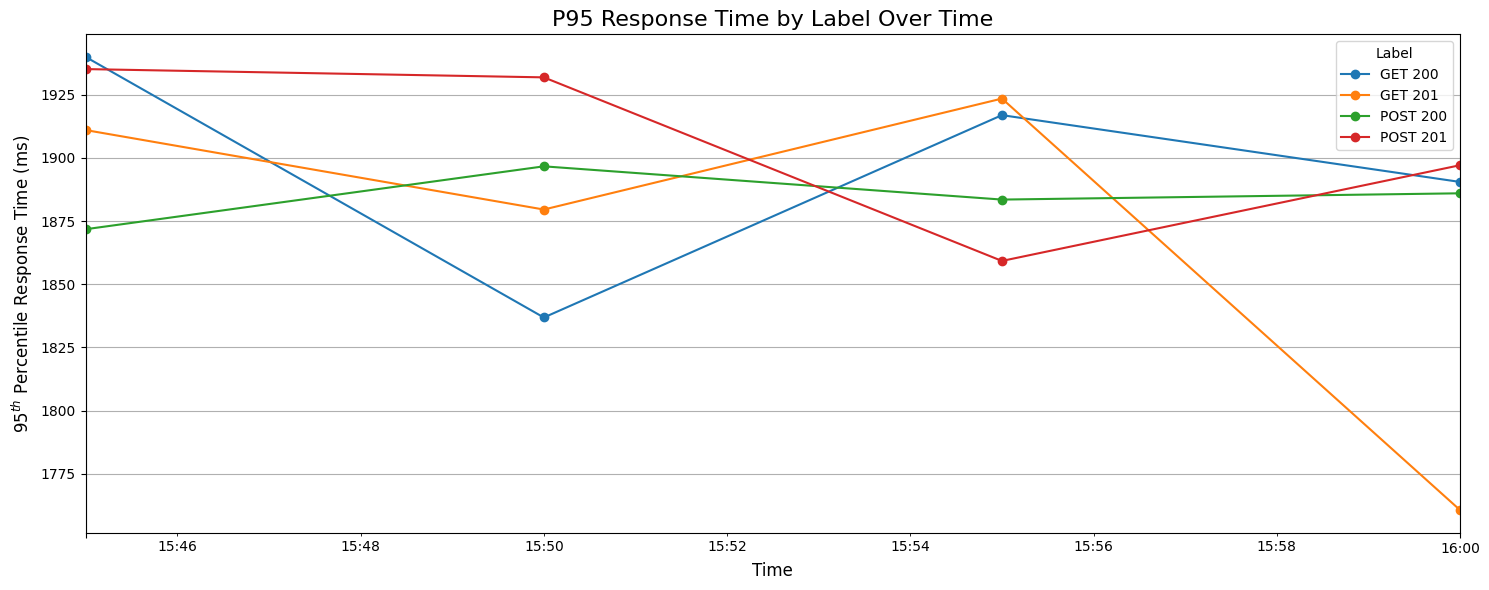

In [45]:
from utils import plot_line_graph

plot_line_graph(aggregated_data_from_cloudwatch_df)

### Manually Aggregating Metrics

In [41]:
labeled_metrics_data_df = metrics_data_df.copy()

# Create a Label column based on dimensions
labeled_metrics_data_df["Label"] = labeled_metrics_data_df["Dimensions"].apply(
    lambda x: f"{x[1]['Value']} {x[2]['Value']}"
)

# Set Timestamp as the index for resampling
labeled_metrics_data_df = labeled_metrics_data_df.set_index("Timestamp")

# Group by Label and resample by 5-minute intervals
aggregated_metric_data_manually = (
    labeled_metrics_data_df.groupby("Label")  # Group by the label first
    .resample("5min")  # Resample each group by 5-minute intervals
    .agg(
        SampleCount=("Value", "count"),
        Average=("Value", "mean"),
        Sum=("Value", "sum"),
        Minimum=("Value", "min"),
        Maximum=("Value", "max"),
        P95=("Value", lambda x: x.quantile(0.95)),
    )
    .reset_index()  # Reset index to make Label and Timestamp regular columns
)

aggregated_metric_data_manually.head()

,Label,Timestamp,SampleCount,Average,Sum,Minimum,Maximum,P95
0,GET 200,2025-01-20 15:45:00+00:00,58,1127.254788,65380.777692,134.213528,1996.875645,1953.458381
1,GET 200,2025-01-20 15:50:00+00:00,83,965.839253,80164.657994,14.962401,1978.684827,1852.989061
2,GET 200,2025-01-20 15:55:00+00:00,94,921.956578,86663.918315,21.410433,1997.660007,1882.066804
3,GET 200,2025-01-20 16:00:00+00:00,31,942.009422,29202.292068,53.618701,1991.305742,1861.451832
4,GET 201,2025-01-20 15:45:00+00:00,60,1092.665734,65559.944046,22.909637,1986.653434,1921.874092


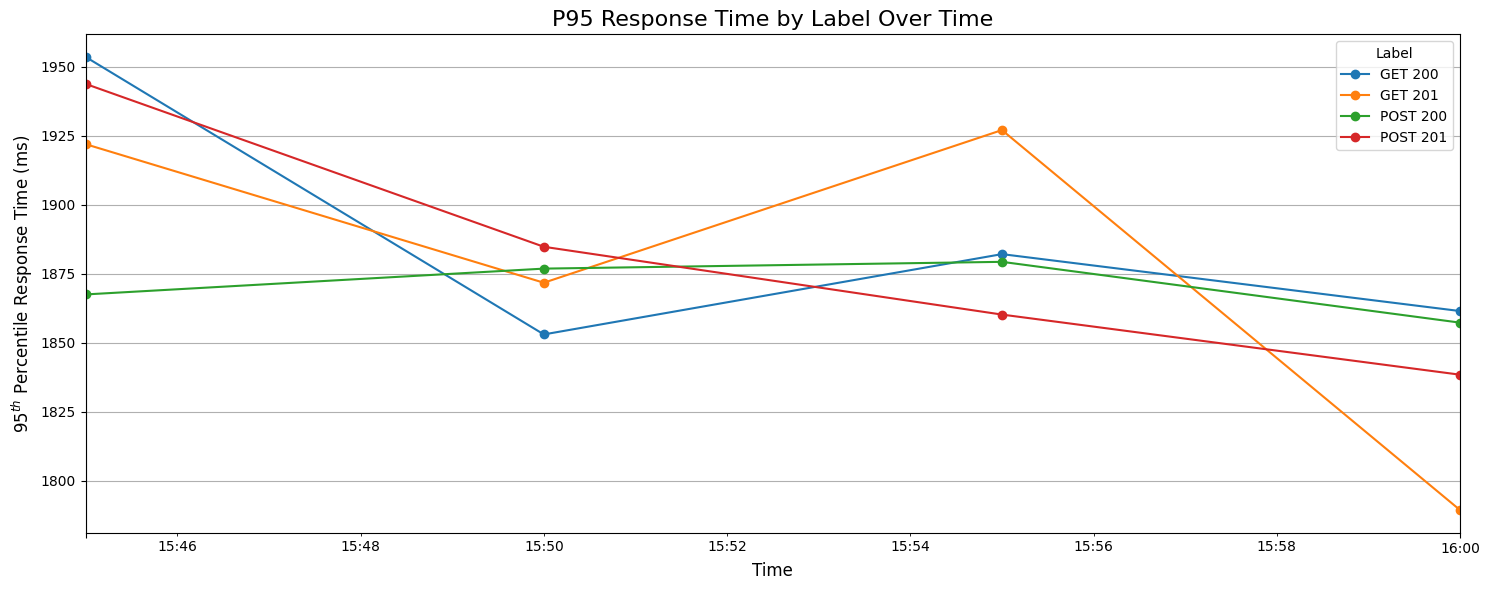

In [46]:
from utils import plot_line_graph

plot_line_graph(aggregated_metric_data_manually)

The same metric graph in Cloudwatch UI. You can see all three are exactly the same.

<!-- ![P95-ResponeLatency](./assets/p95-response-latency-cloudwatch.png) -->
<div style="text-align: center;">
    <figure>
        <img src="./assets/p95-response-latency-cloudwatch.png" alt="P95 Response Latency" style="max-width: 100%; height: auto;">
        <figcaption>P95 Response Latency (CloudWatch)</figcaption>
    </figure>
</div>

## Embedded Metric Format (EMF)

- With the CloudWatch Embedded Metric Format(EMF), you can generate custom metrics asynchronously in the form of logs written to CloudWatch Logs.
- With EMF, you do not require any setup. You either structure your logs in [**EMF-specified format**](https://docs.aws.amazon.com/AmazonCloudWatch/latest/monitoring/CloudWatch_Embedded_Metric_Format_Specification.html) or generate them using [client libraries](https://github.com/awslabs/aws-embedded-metrics-python/tree/master).
- CloudWatch automatically extracts the custom metrics from the logs and creates metrics out of them.

Before we start using libraries like `aws-embedded-metrics` or `aws-lambda-powertools`, let's first understand how to structure our logs in EMF format and how CloudWatch parses them.

In the below example, we are generating logs in EMF format and pushing them to CloudWatch using Cloudwatch using the [`PutLogEvents`](https://docs.aws.amazon.com/AmazonCloudWatchLogs/latest/APIReference/API_PutLogEvents.html) API.

1. First we create a LogGroup and LogStream.
2. Then we push logs in EMF format to the LogStream.

In [6]:
# Set the AWS Profile and Region
import os

# make sure to activate your AWS Profile using `aws configure --profile cloud-course` OR `aws sso login --profile cloud-course`
os.environ["AWS_PROFILE"] = "cloud-course"
os.environ["AWS_DEFAULT_REGION"] = "ap-south-1"

In [7]:
import boto3

try:
    from mypy_boto3_cloudwatch.client import CloudWatchClient
except ImportError:
    print("boto3-stubs not installed. Please install 'boto3-stubs[cloudwatch]'")


LOG_GROUP = "/aws/lambda/local-fastapi"
LOG_STREAM = "custom-embedded-metrics-log-stream"

logs_client: "CloudWatchClient" = boto3.client("logs")


# Step 1: Ensure Log Group Exists
try:
    logs_client.create_log_group(logGroupName=LOG_GROUP)
    print(f"Log group '{LOG_GROUP}' created.")
except logs_client.exceptions.ResourceAlreadyExistsException:
    print(f"Log group '{LOG_GROUP}' already exists. Skipping creation.")

# Step 2: Ensure Log Stream Exists
try:
    logs_client.create_log_stream(logGroupName=LOG_GROUP, logStreamName=LOG_STREAM)
    print(f"Log stream '{LOG_STREAM}' created.")
except logs_client.exceptions.ResourceAlreadyExistsException:
    print(f"Log stream '{LOG_STREAM}' already exists. Skipping creation.")

Log group '/aws/lambda/local-fastapi' already exists. Skipping creation.
Log stream 'custom-embedded-metrics-log-stream' already exists. Skipping creation.


In [ ]:
import json
import boto3
import time
import random
from botocore.exceptions import ClientError

try:
    from mypy_boto3_cloudwatch.client import CloudWatchClient
except ImportError:
    print("boto3-stubs not installed. Please install 'boto3-stubs[cloudwatch]'")


NAMESPACE = "Custom/EMFMetrics"


logs_client: "CloudWatchClient" = boto3.client("logs")


# Step 3: Construct EMF Log
emf_log = {
    "_aws": {
        "Timestamp": int(time.time() * 1000),
        "CloudWatchMetrics": [
            {
                "Namespace": NAMESPACE,
                "Dimensions": [["APIRoute", "HTTPMethod"]],
                "Metrics": [
                    {"Name": "OpenAITokens", "Unit": "Count"},
                    {"Name": "S3BytesUploaded", "Unit": "Bytes"},
                ],
            }
        ],
    },
    "APIRoute": "/generate-text",
    "HTTPMethod": "POST",
    "OpenAITokens": random.randint(1000, 2000),
    "S3BytesUploaded": random.randint(100000, 300000),
}

# Step 4: Retrieve the Next Sequence Token (if exists)
try:
    response = logs_client.describe_log_streams(
        logGroupName=LOG_GROUP, logStreamNamePrefix=LOG_STREAM
    )
    next_token = response["logStreams"][0].get("uploadSequenceToken", None)
except ClientError as e:
    print(f"Error fetching log stream details: {e}")
    next_token = None

# Step 5: Send Log Event
put_log_args = {
    "logGroupName": LOG_GROUP,
    "logStreamName": LOG_STREAM,
    "logEvents": [
        {"timestamp": int(time.time() * 1000), "message": json.dumps(emf_log)}
    ],
}

if next_token:
    put_log_args["sequenceToken"] = next_token  # Include sequence token if available

logs_client.put_log_events(**put_log_args)

print("EMF log sent to CloudWatch!")

EMF log sent to CloudWatch!


You can even create some bizarre logs and CloudWatch will still parse them and create metrics out of them:

```python
    emf_log = {
        "_aws": {
            "Timestamp": int(time.time() * 1000),
            "CloudWatchMetrics": [
                {
                    "Namespace": "Custom/NameSpace1",
                    "Dimensions": [["APIRoute", "HTTPMethod"]],
                    "Metrics": [
                        {"Name": "OpenAITokens1", "Unit": "Count"},
                        {"Name": "S3BytesUploaded1", "Unit": "Bytes"},
                    ],
                },
                {
                    "Namespace": "Custom/NameSpace2",
                    "Dimensions": [["APIRoute", "HTTPMethod"]],
                    "Metrics": [
                        {"Name": "OpenAITokens2", "Unit": "Count"},
                        {"Name": "S3BytesUploaded2", "Unit": "Bytes"},
                    ],
                }
            ],
        },
        "APIRoute": "/generate-text",
        "HTTPMethod": "POST",
        "OpenAITokens1": random.randint(1000, 2000),
        "S3BytesUploaded1": random.randint(100000, 300000),
        "OpenAITokens2": random.randint(1000, 2000),
        "S3BytesUploaded2": random.randint(100000, 300000),
        "Metadata_key": "Metadata_value",
        "Metadata_dict": {"key1": "value1", "key2": "value2"},
        "Metadata_list": ["item1", "item2", "item3"],
    }
```

In [9]:
import json
import fastjsonschema

# Load the schema exactly as it is from AWS documentation
with open("assets/aws_emf_schema.json", "r") as file:
    EMF_LOG_SCHEMA = json.load(file)

# Example JSON data to validate
json_data = {
    "_aws": {
        "Timestamp": 1677891234567,
        "CloudWatchMetrics": [
            {
                "Namespace": "MyApp",
                "Dimensions": [["Operation"]],
                "Metrics": [
                    {"Name": "ProcessingLatency", "Unit": "Milliseconds", "StorageResolution": 60}
                ]
            }
        ]
    }
}

# Compile the schema once for performance
validate = fastjsonschema.compile(EMF_LOG_SCHEMA)

# Validate JSON data
try:
    validate(json_data)
    print("JSON data is valid!")
except fastjsonschema.exceptions.JsonSchemaException as err:
    print(f"JSON data is invalid: {err.message}")


JSON data is valid!


In [8]:
import json
import boto3
import time
import random
from botocore.exceptions import ClientError

try:
    from mypy_boto3_cloudwatch.client import CloudWatchClient
except ImportError:
    print("boto3-stubs not installed. Please install 'boto3-stubs[cloudwatch]'")



logs_client: "CloudWatchClient" = boto3.client("logs")


# Step 3: Construct EMF Log
emf_log = {
    "_aws": {
        "Timestamp": int(time.time() * 1000),
        "CloudWatchMetrics": [
            {
                "Namespace": "Custom/NameSpace1",
                "Dimensions": [["APIRoute", "HTTPMethod"]],
                "Metrics": [
                    {"Name": "OpenAITokens1", "Unit": "Count"},
                    {"Name": "S3BytesUploaded1", "Unit": "Bytes"},
                ],
            },
            {
                "Namespace": "Custom/NameSpace2",
                "Dimensions": [["APIRoute", "HTTPMethod"]],
                "Metrics": [
                    {"Name": "OpenAITokens2", "Unit": "Count"},
                    {"Name": "S3BytesUploaded2", "Unit": "Bytes"},
                ],
            }
        ],
    },
    "APIRoute": "/generate-text",
    "HTTPMethod": "POST",
    "OpenAITokens1": random.randint(1000, 2000),
    "S3BytesUploaded1": random.randint(100000, 300000),
    "OpenAITokens2": random.randint(1000, 2000),
    "S3BytesUploaded2": random.randint(100000, 300000),
    "Metadata_key": "Metadata_value",
    "Metadata_dict": {"key1": "value1", "key2": "value2"},
    "Metadata_list": ["item1", "item2", "item3"],
}

# Step 4: Retrieve the Next Sequence Token (if exists)
try:
    response = logs_client.describe_log_streams(
        logGroupName=LOG_GROUP, logStreamNamePrefix=LOG_STREAM
    )
    next_token = response["logStreams"][0].get("uploadSequenceToken", None)
except ClientError as e:
    print(f"Error fetching log stream details: {e}")
    next_token = None

# Step 5: Send Log Event
put_log_args = {
    "logGroupName": LOG_GROUP,
    "logStreamName": LOG_STREAM,
    "logEvents": [
        {"timestamp": int(time.time() * 1000), "message": json.dumps(emf_log)}
    ],
}

if next_token:
    put_log_args["sequenceToken"] = next_token  # Include sequence token if available

logs_client.put_log_events(**put_log_args)

print("EMF log sent to CloudWatch!")

EMF log sent to CloudWatch!


<div style="display: flex; justify-content: center; gap: 2px; align-items: center;">
    <div style="text-align: center;">
        <img src="./assets/emf_metric_log_in_CW_Logs.png" alt="EMF Log">
        <p><strong>Figure 1:</strong> EMF Log in CloudWatch Logs</p>
    </div>
    <div style="text-align: center;">
        <img src="./assets/emf_metric_in_CW_Metrics.png" alt="EMF Metric">
        <p><strong>Figure 2:</strong> EMF Metric in CloudWatch Metrics</p>
    </div>
</div>

## [`aws-embedded-metrics`](https://github.com/awslabs/aws-embedded-metrics-python/tree/master)

- In essence, the `aws-embedded-metrics` library does the same thing as we did in the previous example, where we manually structured our logs in EMF format and pushed them to CloudWatch Logs.

- It provides you with a more sophisticated way to write custom metrics in your app and abstracts away the complexity of formatting them in EMF log format and pushing them to CloudWatch Logs.

- Apart from AWS Lambda, the library supports sending custom metrics to Cloudwatch from various compute environments like On-prem, EC2, container environments like ECS, Fargate, EKS, etc.

- You do not need to worry about batching you logs, making network calls to Cloudwatch, or retrying failed requests. The library takes care of all these things for you.

- The `set_property` method allows you to attach contextual metadata to your EMF logs without storing it as a CloudWatch metric.
  - This data is not indexed as a metric, but it remains searchable in CloudWatch Logs Insights.
  
  - This can be useful for contextual and potentially high-cardinality data(e.g., request IDs, user IDs, IP addresses) that is not appropriate for CloudWatch Metrics dimensions but might be useful for debugging or analysis.

  - The library automatically injects environment metadata such as Lambda Function version, EC2 instance and image ids into the structured log event data.


The way to publish metrics with `aws-embedded-metrics` library is via the `MetricLogger` interface. And to get the metric logger, you decorate you function with `@metric_scope` decorator.

Please see the example in the following cells and refer to their [**GitHub repo**](https://github.com/awslabs/aws-embedded-metrics-python) to know more about the library.

In [1]:
! pip install -q "aws-embedded-metrics" nest_asyncio tqdm


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


The EMF support the following configuration options:

In [2]:
import os

# causes metrics to go to stdout; the library tries to automatically infer the environment.
os.environ["AWS_EMF_ENVIRONMENT"] = "local"

# Service Name and Type -- If you want to override the inferred service name and type
os.environ["AWS_EMF_SERVICE_NAME"] = "local-jupyter-notebook"
os.environ["AWS_EMF_SERVICE_TYPE"] = "jupyter-notebook"

# Namespace for the metrics -- Ideally, you would want to set this as per your preference, default namespace is 'aws-embedded-metrics'
os.environ["AWS_EMF_NAMESPACE"] = "Custom/EMFMetrics"  # Namespace for the metrics

# You can sepecify the log group and log stream names if you want to send the metrics to a specific log group and log stream
os.environ["AWS_EMF_LOG_GROUP_NAME"] = "/aws/lambda/local-fastapi"
os.environ["AWS_EMF_LOG_STREAM_NAME"] = "local-emf-metrics-log-stream"

# Set to 'true' to enable debug logging
os.environ["AWS_EMF_ENABLE_DEBUG_LOGGING"] = "false"

# Set to 'true' to prevent logging metrics to cloudwatch by omitting EMF metadata from logs.
# This basically converts the emf log messages to a simple JSON log message
os.environ["AWS_EMF_DISABLE_METRIC_EXTRACTION"] = "false"

You can even set these configuration values using a `Config` object in your code.

```python
    from aws_embedded_metrics.config import get_config

    Config = get_config()
    Config.environment = "local"
    Config.service_name = "local-jupyter-notebook"
    Config.service_type = "jupyter-notebook"
    Config.namespace = "Custom/EMFMetrics"
    Config.debug_logging_enabled = True
    Config.log_group_name = "/aws/lambda/local-fastapi"
    Config.log_stream_name = "local-emf-metrics-log-stream"
    Config.disable_metric_extraction = False
```

In [3]:
import nest_asyncio

nest_asyncio.apply()


import time
import random
from aws_embedded_metrics import metric_scope
from aws_embedded_metrics.storage_resolution import StorageResolution
from aws_embedded_metrics.logger.metrics_logger import MetricsLogger
from tqdm.notebook import trange

# Simulated API Routes
API_ROUTES = ["/generate-text", "/summarize", "/translate", "/analyze-sentiment"]
HTTP_METHOD = ["POST", "GET", "HEAD", "PUT"]


# Simulating API Requests
@metric_scope
def simulate_api_requests(metrics: MetricsLogger) -> None:
    """Simulates an API request and logs key metrics to CloudWatch."""

    # Simulate API call data
    api_route = random.choice(API_ROUTES)
    http_method = random.choice(HTTP_METHOD)
    token_count = random.randint(100, 2000)  # Tokens used
    response_time = round(random.uniform(0.1, 2.5), 2)  # Response latency in seconds
    s3_bytes_uploaded = token_count * 512  # Approximate data uploaded per request
    success = random.random() > 0.1  # 10% chance of failure

    # Remove default dimensions
    # metrics.reset_dimensions(use_default=False)

    # Attach dimensions
    # metrics.put_dimensions({"APIRoute": api_route, "HTTPMethod": http_method})

    # Send core metrics
    # StorageResolution: Can be either 1 or 60; 1 for High Resolution and 60 for Standard Resolution; default is Standard Resolution (60)
    metrics.put_metric("OpenAITokens", token_count, "Count", StorageResolution.STANDARD)
    metrics.put_metric(
        "S3BytesUploaded", s3_bytes_uploaded, "Bytes", StorageResolution.STANDARD
    )
    metrics.put_metric(
        "ResponseTime", response_time, "Seconds", StorageResolution.STANDARD
    )

    # Track error rate
    if not success:
        metrics.put_metric("ErrorCount", 1, "Count", StorageResolution.STANDARD)

    # Add metadata
    metrics.set_property("RequestId", f"req-{random.randint(1000, 9999)}")
    metrics.set_property("CustomProperty", {"key1": "value1", "key2": "value2"})

    # Simulate API processing time
    time.sleep(response_time)


# Run multiple simulated API requests
print("🚀 Running API request simulation...\n")
for _ in trange(20):  # Simulate 20 API calls
    simulate_api_requests()

🚀 Running API request simulation...



  0%|          | 0/20 [00:00<?, ?it/s]

{"LogGroup": "/aws/lambda/local-fastapi", "ServiceName": "local-jupyter-notebook", "ServiceType": "jupyter-notebook", "RequestId": "req-8868", "CustomProperty": {"key1": "value1", "key2": "value2"}, "_aws": {"Timestamp": 1748843613166, "CloudWatchMetrics": [{"Dimensions": [["LogGroup", "ServiceName", "ServiceType"]], "Metrics": [{"Name": "OpenAITokens", "Unit": "Count"}, {"Name": "S3BytesUploaded", "Unit": "Bytes"}, {"Name": "ResponseTime", "Unit": "Seconds"}, {"Name": "ErrorCount", "Unit": "Count"}], "Namespace": "Custom/EMFMetrics"}]}, "OpenAITokens": 1775, "S3BytesUploaded": 908800, "ResponseTime": 2.44, "ErrorCount": 1}
{"LogGroup": "/aws/lambda/local-fastapi", "ServiceName": "local-jupyter-notebook", "ServiceType": "jupyter-notebook", "RequestId": "req-7527", "CustomProperty": {"key1": "value1", "key2": "value2"}, "_aws": {"Timestamp": 1748843615613, "CloudWatchMetrics": [{"Dimensions": [["LogGroup", "ServiceName", "ServiceType"]], "Metrics": [{"Name": "OpenAITokens", "Unit": "Cou

Here is a sample EMF Log from our Flies API running in a Lambda Environment.

```json
    {
        "route": "/v1/files/{file_path:path}",
        "method": "PUT",
        "tracing": {
            "xray-trace-id": "1-67b8680b-68f3a0a507bee93874e2fce5",
            "xray-segment-id": "835fb9bdcfe768e7",
            "xray-parent-id": null
        },
        "http": {
            "path": "/v1/files/test_file_5880.txt",
            "route": "/v1/files/{file_path:path}",
            "method": "PUT"
        },
        "executionEnvironment": "AWS_Lambda_python3.12",
        "memorySize": "128",
        "functionVersion": "$LATEST",
        "logStreamId": "2025/02/21/[$LATEST]97d96d856bf048d796e24e2ecabe9209",
        "traceId": "Root=1-67b8680b-68f3a0a507bee93874e2fce5;Parent=835fb9bdcfe768e7;Sampled=1;Lineage=1:8f80c61b:0",
        "_aws": {
            "Timestamp": 1740138507131,
            "CloudWatchMetrics": [
                {
                    "Dimensions": [
                        [
                            "route",
                            "method"
                        ]
                    ],
                    "Metrics": [
                        {
                            "Name": "S3BytesUploaded",
                            "Unit": "Bytes"
                        }
                    ],
                    "Namespace": "files-api"
                }
            ]
        },
        "S3BytesUploaded": 28
    }
```

You can see along with the custom metric `S3BytesUploaded`, the log also contains some contextual metadata that we added like `tracing`, `http`, and some auto-injected metadata by the emf library like `traceId`, `logStreamId`, `functionVersion`, `memorySize`, etc.

## [`aws-lambda-powertools`](https://docs.powertools.aws.dev/lambda/python/latest/)

The `aws-lambda-powertools` library is wrapper around the `aws-embedded-metrics` library that provided additional features and a better devX tailored for AWS Lambda functions.
Apart from logging metrics, the lambda powertools library also provdies logging and tracing capabilities.

Please visit their docs page to learn more. In our course, we will be using `aws-embedded-metrics` library for sending custom metrics to CloudWatch.